# Spinon mean-field theory of quantum spin models

`SpinonHamiltonian` (`pyqula.spinon`) treats a pure spin-$\tfrac12$ Heisenberg model
$H=J\sum_{\langle ij\rangle}\vec S_i\cdot\vec S_j$ on its own terms via the Abrikosov-pseudofermion
representation $\vec S_i=\tfrac12 f_i^\dagger\vec\sigma f_i$ (Savary & Balents, arXiv:1601.03742,
Sec. 4): each spin becomes an auxiliary ("spinon") fermion under the hard local constraint
$f_i^\dagger f_i=1$, exactly one fermion per site, enforced individually via a per-site Lagrange
multiplier co-converged in the same SCF loop as the RVB bond order parameter
$\chi_{ij}=\langle f_i^\dagger f_j\rangle$. An external field couples exactly (not via any
mean-field decoupling, since $\vec S_i$ is already bilinear in $f$) and competes with the exchange,
saturating the induced moment once it dominates $J$.

Converged <n_i> per site (target 1.0): [1.]


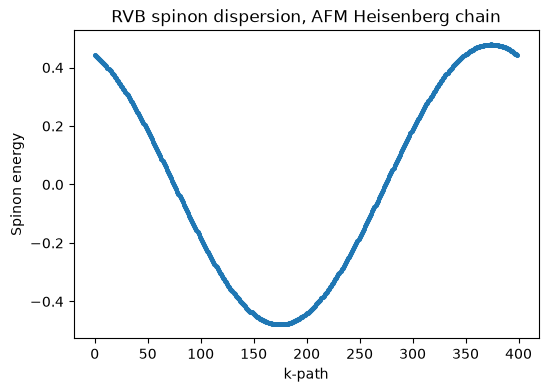

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula.spinon import SpinonHamiltonian

np.random.seed(0)
g = geometry.chain()
h = SpinonHamiltonian(g) # zero bare hopping: a pure spin model
h2 = h.get_mean_field_hamiltonian(J1=1.0,nk=24,mix=0.3,maxerror=1e-5,maxite=2000)

print("Converged <n_i> per site (target 1.0):",h2.local_occupation)
(k,e) = h2.get_bands()

plt.figure(figsize=(6,4))
plt.scatter(k,e,s=6)
plt.xlabel("k-path") ; plt.ylabel("Spinon energy")
plt.title("RVB spinon dispersion, AFM Heisenberg chain")
plt.show()

An external Zeeman field, applied before `get_mean_field_hamiltonian`, induces a magnetization that grows with field while the local constraint stays exactly satisfied:

No convergence has been reached in 2000 iterations, stopping


No convergence has been reached in 2000 iterations, stopping


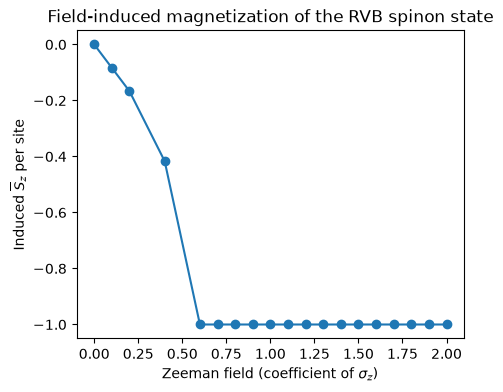

In [2]:
fields = np.linspace(0.0,2.0,21)
done_fields,magnetizations,spinon_hamiltonians = [],[],[]
for b in fields:
    np.random.seed(0)
    hb = SpinonHamiltonian(g)
    hb.add_zeeman([0.,0.,b])
    h2b = hb.get_mean_field_hamiltonian(J1=1.0,nk=24,mix=0.3,maxerror=1e-6,maxite=2000)
    if h2b is None: continue # SCF can fail to converge right at a metamagnetic jump
    done_fields.append(b)
    magnetizations.append(h2b.get_magnetization()[0][2])
    spinon_hamiltonians.append(h2b)

plt.figure(figsize=(5,4))
plt.plot(done_fields,magnetizations,marker="o")
plt.xlabel(r"Zeeman field (coefficient of $\sigma_z$)")
plt.ylabel(r"Induced $\overline{S}_z$ per site")
plt.title("Field-induced magnetization of the RVB spinon state")
plt.show()

The spin-resolved spinon density of states as a function of the field shows where that
magnetization comes from: the field pulls the spin-up and spin-down spinon bands apart, and once
the moment saturates the spin-down band is full and the spin-up one empty, so that the bond order
parameter $\chi_{ij}$ vanishes and both bands turn flat.

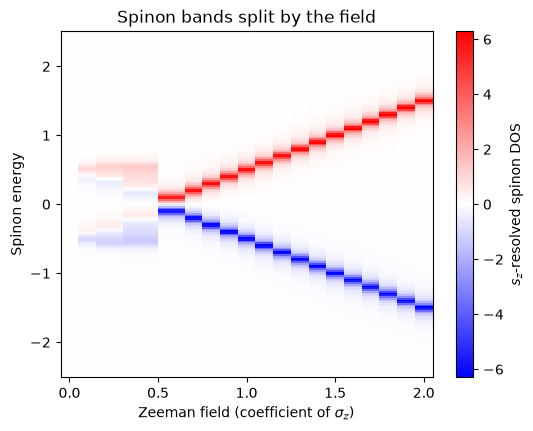

In [3]:
energies = np.linspace(-2.5,2.5,200)
dos_sz = [] # spinon DOS weighted by s_z, one row per field
for hb in spinon_hamiltonians:
    (es,d) = hb.get_dos(energies=energies,delta=5e-2,nk=200,operator="sz",write=False)
    dos_sz.append(d)
dos_sz = np.array(dos_sz)

dmax = np.max(np.abs(dos_sz)) # symmetric color scale
plt.figure(figsize=(6,4.5))
plt.pcolormesh(done_fields,energies,dos_sz.T,cmap="bwr",vmin=-dmax,vmax=dmax,shading="nearest")
plt.colorbar(label="$s_z$-resolved spinon DOS")
plt.xlabel(r"Zeeman field (coefficient of $\sigma_z$)") ; plt.ylabel("Spinon energy")
plt.title("Spinon bands split by the field")
plt.show()